c:\Users\gaurav\anaconda3\envs\ml_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Fetching real UCI Taiwan Loan dataset via scikit-learn OpenML...

--- Initiating Model Training & Tuning ---
checkpoint directory created: ./model
saving model version 0.0

Calculating Predictive Metrics on Test Set...

Running Global Stability Evaluation on 50 Test Instances...

FINAL COMPREHENSIVE BENCHMARK RESULTS
********************************************************************************************************************************************
Note: EMS (Magnitude Stability) should ONLY be compared directly within the same 'Family'.
Jaccard (Top-5), ERS, and CES are unitless and can be compared globally across all models.

--- SHAP MODELS ---
                   Model / Explainer Accuracy ↑ EMS (Lipschitz Bound) ↓ Top-5 Jaccard ↑ ERS (Rank Stability) ↑ CES (Direction Shift) ↓
          Mono XGBoost + Native SHAP     0.8173         0.5562 ± 0.4268 0.7305 ± 0.1539        0.8402 ± 0.1138         0.0920 ± 0.1217
                Tuned RF + Tree SHAP     0.8128         0.1351 ± 0

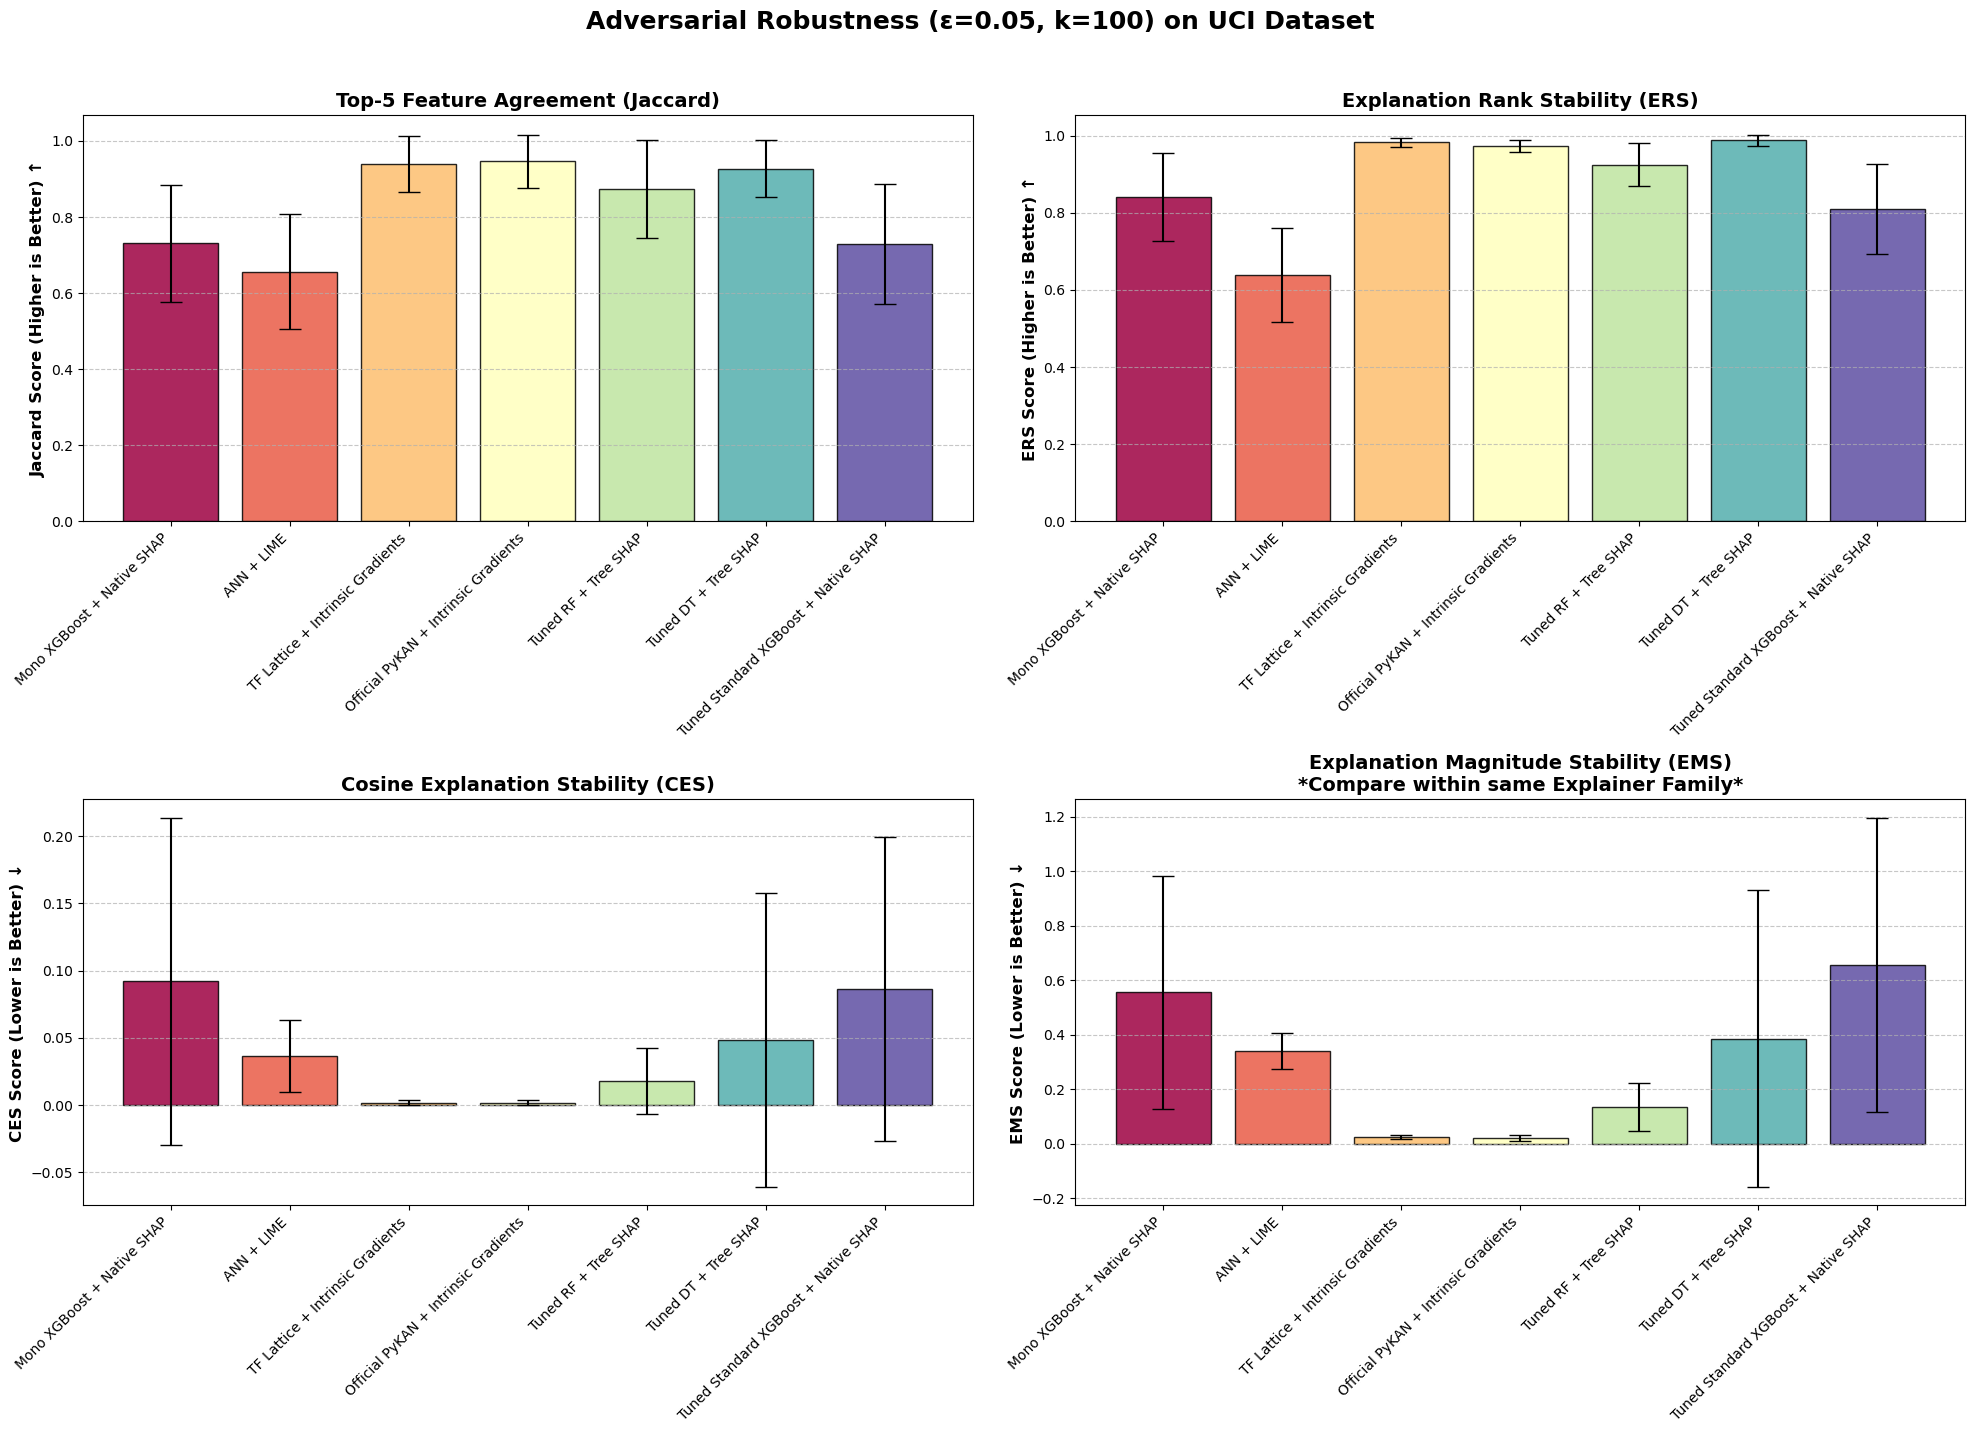

In [1]:
import os
# This MUST be set before importing tensorflow to ensure TF Lattice (Keras 2) works
os.environ['TF_USE_LEGACY_KERAS'] = '1'

import numpy as np
import pandas as pd
from scipy.stats import spearmanr, pearsonr
from scipy.spatial.distance import cosine
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_openml
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, mean_squared_error
import xgboost as xgb
import shap
import lime
import lime.lime_tabular
import torch
import torch.nn as nn
import torch.optim as optim
import tensorflow as tf
import tensorflow_lattice as tfl
from kan import KAN  # Official PyKAN Library
import warnings
import matplotlib.pyplot as plt
import re

# Suppress warnings for cleaner output during execution
warnings.filterwarnings("ignore")
tf.get_logger().setLevel('ERROR')

# ==========================================
# 0. GLOBAL EXPERIMENT HYPERPARAMETERS
# ==========================================
EPSILON = 0.05              # Radius of perturbation (5% of standardized feature's std dev)
K_PERTURBATIONS = 100       # Number of local noise samples
N_EVAL_SAMPLES = 50         # Number of test set instances for stability metrics
CV_FOLDS = 3                # Hyperparameter GridSearch folds
TOP_K_FEATURES = 5          # Number of top features to evaluate for Jaccard Agreement

# ==========================================
# 1. FETCH AND PREPARE REAL UCI DATA
# ==========================================
print("Fetching real UCI Taiwan Loan dataset via scikit-learn OpenML...")
dataset = fetch_openml(data_id=42477, as_frame=True, parser='auto')
df = dataset.frame

target_col = dataset.target_names[0]         
X = df.drop(columns=[target_col]).values.astype(np.float32)
y = df[target_col].values.astype(int)
feature_names = df.drop(columns=[target_col]).columns.tolist()

# Continuous features to perturb
continuous_indices = [0, 4, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_bg = X_train_scaled[:100] # Background dataset for probability SHAP integration

# ==========================================
# 2. RIGOROUS STABILITY METRICS & PERTURBATION
# ==========================================
def generate_tabular_perturbations(x, continuous_indices, epsilon, k):
    x_perturbed = np.tile(x, (k, 1)).astype(float)
    for idx in continuous_indices:
        x_perturbed[:, idx] += np.random.normal(0, epsilon, k)
    return x_perturbed

def calculate_top_k_jaccard(exp_x, exp_perturbed, k=TOP_K_FEATURES):
    """
    Top-K Feature Agreement (Jaccard Similarity).
    Unitless, explainer-agnostic metric evaluating if the most critical features change.
    """
    base_attr = np.abs(exp_x.flatten())
    # argsort sorts ascending, so [-k:] gets the indices of the largest absolute values
    base_top_k = set(np.argsort(base_attr)[-k:])
    
    jaccard_scores = []
    for i in range(exp_perturbed.shape[0]):
        pert_attr = np.abs(exp_perturbed[i].flatten())
        pert_top_k = set(np.argsort(pert_attr)[-k:])
        
        intersection = len(base_top_k.intersection(pert_top_k))
        union = len(base_top_k.union(pert_top_k))
        jaccard_scores.append(intersection / union if union > 0 else 0.0)
        
    return np.mean(jaccard_scores)

def calculate_ces(exp_x, exp_perturbed):
    """Cosine Explanation Stability (Directional alignment)."""
    distances = []
    base_vector = exp_x.flatten()
    for i in range(exp_perturbed.shape[0]):
        pert_vector = exp_perturbed[i].flatten()
        dist = cosine(base_vector, pert_vector)
        if np.isnan(dist):
            dist = 0.0 if np.all(base_vector == 0) and np.all(pert_vector == 0) else 1.0
        distances.append(dist)
    return np.mean(distances)

def calculate_ers(exp_x, exp_perturbed):
    """Explanation Rank Stability (ERS) using raw absolute values."""
    base_attr = np.abs(exp_x.flatten())
    correlations = []
    for i in range(exp_perturbed.shape[0]):
        pert_attr = np.abs(exp_perturbed[i].flatten())
        corr, _ = spearmanr(base_attr, pert_attr)
        correlations.append(0.0 if np.isnan(corr) else corr)
    return np.mean(correlations)

def calculate_ems(x, x_perturbed, exp_x, exp_perturbed):
    """Explanation Magnitude Stability (EMS) - Local Lipschitz estimate."""
    dist_exp = np.linalg.norm(exp_perturbed - exp_x, axis=1)
    dist_x = np.linalg.norm(x_perturbed - x, axis=1) + 1e-9 
    return np.max(dist_exp / dist_x)

def evaluate_instance_stability(x, model_explainer_fn, continuous_indices, epsilon, k_pert):
    exp_x = model_explainer_fn(x) 
    x_perturbed = generate_tabular_perturbations(x, continuous_indices, epsilon, k_pert)
    exp_perturbed = model_explainer_fn(x_perturbed)
        
    ems_score = calculate_ems(x, x_perturbed, exp_x, exp_perturbed)
    ers_score = calculate_ers(exp_x, exp_perturbed)
    ces_score = calculate_ces(exp_x, exp_perturbed)
    jaccard_score = calculate_top_k_jaccard(exp_x, exp_perturbed, k=TOP_K_FEATURES)
    
    return ems_score, ers_score, ces_score, jaccard_score

# ==========================================
# 3. TRAIN MODELS AND BUILD WRAPPERS 
# ==========================================
constraints = tuple([-1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, -1, -1, -1, -1, -1, -1])
cv_strategy = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=42)
print(f"\n--- Initiating Model Training & Tuning ---")

# --- A. Monotonic XGBoost ---
xgb_mono_base = xgb.XGBClassifier(monotone_constraints=constraints, random_state=42, eval_metric='logloss')
xgb_mono_grid = GridSearchCV(xgb_mono_base, {'n_estimators': [50], 'max_depth': [3]}, cv=cv_strategy)
xgb_mono_grid.fit(X_train_scaled, y_train)
xgb_mono = xgb_mono_grid.best_estimator_

xgb_mono_explainer = shap.TreeExplainer(xgb_mono, data=X_bg, model_output='probability', feature_perturbation='interventional')
def xgb_mono_shap_wrapper(X_input):
    sv = xgb_mono_explainer.shap_values(X_input)
    if isinstance(sv, list): return np.array(sv[1])
    if len(sv.shape) == 3: return sv[:, :, 1]
    return sv

# --- B. PyTorch ANN ---
class CreditANN(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Sequential(nn.Linear(X.shape[1], 64), nn.ReLU(), nn.Linear(64, 32), nn.ReLU(), nn.Linear(32, 1))
    def forward(self, x): return self.fc(x)

ann_model = CreditANN()
optimizer = optim.Adam(ann_model.parameters(), lr=0.01)
criterion = nn.BCEWithLogitsLoss()
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
ann_model.train()
for epoch in range(50):
    optimizer.zero_grad()
    loss = criterion(ann_model(X_train_tensor), y_train_tensor)
    loss.backward()
    optimizer.step()
ann_model.eval()

class ProbANN(nn.Module):
    def __init__(self, base_model):
        super().__init__()
        self.base = base_model
    def forward(self, x): return torch.sigmoid(self.base(x))

prob_ann_model = ProbANN(ann_model)
deep_explainer = shap.DeepExplainer(prob_ann_model, torch.tensor(X_bg, dtype=torch.float32))

def ann_shap_wrapper(X_input):
    shap_values = deep_explainer.shap_values(torch.tensor(X_input, dtype=torch.float32))
    if isinstance(shap_values, list): return np.array(shap_values[-1])
    shap_array = np.array(shap_values)
    if len(shap_array.shape) == 3: return shap_array[:, :, -1] 
    return shap_array

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_scaled, feature_names=feature_names,
    class_names=['No Default', 'Default'], mode='classification', random_state=42
)

def ann_predict_proba(X_numpy):
    with torch.no_grad():
        probs_class_1 = prob_ann_model(torch.tensor(X_numpy, dtype=torch.float32)).squeeze().numpy()
        probs_class_0 = 1.0 - probs_class_1
    if probs_class_1.ndim == 0: return np.array([[probs_class_0, probs_class_1]])
    return np.vstack((probs_class_0, probs_class_1)).T

def ann_lime_wrapper(X_input):
    n_instances, n_feats = X_input.shape
    lime_exps = np.zeros((n_instances, n_feats))
    for i in range(n_instances):
        exp = lime_explainer.explain_instance(X_input[i], ann_predict_proba, num_features=n_feats)
        for feature_idx, weight in exp.as_map()[1]: lime_exps[i, feature_idx] = weight
    return lime_exps

# --- C. TensorFlow Lattice ---
class TFLatticeModel(tf.keras.Model):
    def __init__(self, num_features, model_constraints):
        super(TFLatticeModel, self).__init__()
        self.tfl_linear = tfl.layers.Linear(num_input_dims=num_features, monotonicities=model_constraints)
        self.sigmoid = tf.keras.layers.Activation('sigmoid')
    def call(self, inputs): return self.sigmoid(self.tfl_linear(inputs))

tfl_model = TFLatticeModel(X.shape[1], constraints)
tfl_model.compile(optimizer='adam', loss='binary_crossentropy')
tfl_model.build(input_shape=(None, X.shape[1])) 
tfl_model.fit(X_train_scaled, y_train, epochs=20, verbose=0)

def tf_lattice_wrapper(X_input):
    X_tensor = tf.convert_to_tensor(X_input, dtype=tf.float32)
    with tf.GradientTape() as tape:
        tape.watch(X_tensor)
        preds = tfl_model(X_tensor) 
    return (tape.gradient(preds, X_tensor) * X_tensor).numpy()

# --- D. Official PyKAN ---
kan_model = KAN(width=[X.shape[1], 8, 1], grid=3, k=3, seed=42)
optimizer_kan = optim.Adam(kan_model.parameters(), lr=0.01)
kan_model.train()
for epoch in range(50):
    optimizer_kan.zero_grad()
    loss = criterion(kan_model(X_train_tensor), y_train_tensor)
    loss.backward()
    optimizer_kan.step()
kan_model.eval()

def kan_intrinsic_wrapper(X_input):
    X_tensor = torch.tensor(X_input, dtype=torch.float32, requires_grad=True)
    preds = torch.sigmoid(kan_model(X_tensor))
    preds.sum().backward()
    attributions = (X_tensor.grad * X_tensor).detach().numpy()
    return attributions

# --- E. Tuned Random Forest ---
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42, n_jobs=-1), {'n_estimators': [50], 'max_depth': [5]}, cv=cv_strategy)
rf_grid.fit(X_train_scaled, y_train)
rf_model = rf_grid.best_estimator_

rf_explainer = shap.TreeExplainer(rf_model, data=X_bg, model_output='probability', feature_perturbation='interventional')
def rf_shap_wrapper(X_input):
    sv = rf_explainer.shap_values(X_input)
    if isinstance(sv, list): return np.array(sv[1])
    if len(sv.shape) == 3: return sv[:, :, 1]
    return sv

# --- F. Tuned Decision Tree ---
dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42), {'max_depth': [5]}, cv=cv_strategy)
dt_grid.fit(X_train_scaled, y_train)
dt_model = dt_grid.best_estimator_

dt_explainer = shap.TreeExplainer(dt_model, data=X_bg, model_output='probability', feature_perturbation='interventional')
def dt_shap_wrapper(X_input):
    sv = dt_explainer.shap_values(X_input)
    if isinstance(sv, list): return np.array(sv[1])
    if len(sv.shape) == 3: return sv[:, :, 1]
    return sv

# --- G. Tuned Standard XGBoost ---
xgb_std_grid = GridSearchCV(xgb.XGBClassifier(random_state=42, eval_metric='logloss'), {'n_estimators': [50], 'max_depth': [3]}, cv=cv_strategy)
xgb_std_grid.fit(X_train_scaled, y_train)
xgb_std = xgb_std_grid.best_estimator_

xgb_std_explainer = shap.TreeExplainer(xgb_std, data=X_bg, model_output='probability', feature_perturbation='interventional')
def xgb_std_shap_wrapper(X_input):
    sv = xgb_std_explainer.shap_values(X_input)
    if isinstance(sv, list): return np.array(sv[1])
    if len(sv.shape) == 3: return sv[:, :, 1]
    return sv

# ==========================================
# 4. PREDICTIVE PERFORMANCE EVALUATION
# ==========================================
print("\nCalculating Predictive Metrics on Test Set...")
predictive_metrics = {}

def get_metrics(y_true, y_prob):
    y_pred = (y_prob >= 0.5).astype(int)
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_prob)),
    }

predictive_metrics["Mono XGBoost + Native SHAP"] = get_metrics(y_test, xgb_mono.predict_proba(X_test_scaled)[:, 1])
with torch.no_grad():
    prob_ann = prob_ann_model(torch.tensor(X_test_scaled, dtype=torch.float32)).squeeze().numpy()
predictive_metrics["ANN + Deep SHAP"] = get_metrics(y_test, prob_ann)
predictive_metrics["ANN + LIME"] = get_metrics(y_test, prob_ann)
predictive_metrics["TF Lattice + Intrinsic Gradients"] = get_metrics(y_test, tfl_model(tf.convert_to_tensor(X_test_scaled, dtype=tf.float32)).numpy().squeeze())
with torch.no_grad():
    prob_kan = torch.sigmoid(kan_model(torch.tensor(X_test_scaled, dtype=torch.float32))).squeeze().numpy()
predictive_metrics["Official PyKAN + Intrinsic Gradients"] = get_metrics(y_test, prob_kan)
predictive_metrics["Tuned RF + Tree SHAP"] = get_metrics(y_test, rf_model.predict_proba(X_test_scaled)[:, 1])
predictive_metrics["Tuned DT + Tree SHAP"] = get_metrics(y_test, dt_model.predict_proba(X_test_scaled)[:, 1])
predictive_metrics["Tuned Standard XGBoost + Native SHAP"] = get_metrics(y_test, xgb_std.predict_proba(X_test_scaled)[:, 1])

# ==========================================
# 5. GLOBAL STABILITY EVALUATION LOOP
# ==========================================
# Grouping dictionary for logical output formatting (Path 1)
model_families = {
    "Mono XGBoost + Native SHAP": "SHAP Models",
    "ANN + Deep SHAP": "SHAP Models",
    "Tuned RF + Tree SHAP": "SHAP Models",
    "Tuned DT + Tree SHAP": "SHAP Models",
    "Tuned Standard XGBoost + Native SHAP": "SHAP Models",
    "TF Lattice + Intrinsic Gradients": "Intrinsic Gradients",
    "Official PyKAN + Intrinsic Gradients": "Intrinsic Gradients",
    "ANN + LIME": "LIME Explainer"
}

wrappers = {
    "Mono XGBoost + Native SHAP": xgb_mono_shap_wrapper,
    "ANN + Deep SHAP": ann_shap_wrapper,
    "ANN + LIME": ann_lime_wrapper,
    "TF Lattice + Intrinsic Gradients": tf_lattice_wrapper,
    "Official PyKAN + Intrinsic Gradients": kan_intrinsic_wrapper,
    "Tuned RF + Tree SHAP": rf_shap_wrapper,
    "Tuned DT + Tree SHAP": dt_shap_wrapper,
    "Tuned Standard XGBoost + Native SHAP": xgb_std_shap_wrapper
}

np.random.seed(42)
eval_indices = np.random.choice(len(X_test_scaled), N_EVAL_SAMPLES, replace=False)
X_eval = X_test_scaled[eval_indices]

print(f"\nRunning Global Stability Evaluation on {N_EVAL_SAMPLES} Test Instances...")
results_dict = {name: {"ems": [], "ers": [], "ces": [], "jaccard": []} for name in wrappers.keys()}

for i in range(N_EVAL_SAMPLES):
    x_instance = X_eval[i:i+1]
        
    for model_name, wrapper_fn in wrappers.items():
        try:
            ems, ers, ces, jac = evaluate_instance_stability(
                x=x_instance, 
                model_explainer_fn=wrapper_fn,
                continuous_indices=continuous_indices,
                epsilon=EPSILON,          
                k_pert=K_PERTURBATIONS
            )
            results_dict[model_name]["ems"].append(ems)
            results_dict[model_name]["ers"].append(ers)
            results_dict[model_name]["ces"].append(ces)
            results_dict[model_name]["jaccard"].append(jac)
        except Exception as e:
            pass

# ==========================================
# 6. COMPILE AND EXPORT RESULTS
# ==========================================
final_results = []
for model_name, metrics in results_dict.items():
    ems_list = metrics["ems"]
    ers_list = metrics["ers"]
    ces_list = metrics["ces"]
    jac_list = metrics["jaccard"]
    pred_mets = predictive_metrics[model_name]
    
    if ems_list:
        final_results.append({
            "Family": model_families[model_name],
            "Model / Explainer": model_name,
            "Accuracy ↑": f"{pred_mets['Accuracy']:.4f}",
            "EMS (Lipschitz Bound) ↓": f"{np.mean(ems_list):.4f} ± {np.std(ems_list):.4f}",
            f"Top-{TOP_K_FEATURES} Jaccard ↑": f"{np.mean(jac_list):.4f} ± {np.std(jac_list):.4f}",
            "ERS (Rank Stability) ↑": f"{np.mean(ers_list):.4f} ± {np.std(ers_list):.4f}",
            "CES (Direction Shift) ↓": f"{np.mean(ces_list):.4f} ± {np.std(ces_list):.4f}"
        })

results_df = pd.DataFrame(final_results)

print("\n" + "="*140)
print("FINAL COMPREHENSIVE BENCHMARK RESULTS")
print("*" * 140)
print("Note: EMS (Magnitude Stability) should ONLY be compared directly within the same 'Family'.")
print(f"Jaccard (Top-{TOP_K_FEATURES}), ERS, and CES are unitless and can be compared globally across all models.")
print("="*140)

# Print grouped to reinforce Path 1 methodology visually
for family in results_df['Family'].unique():
    print(f"\n--- {family.upper()} ---")
    family_df = results_df[results_df['Family'] == family].drop(columns=['Family'])
    print(family_df.to_string(index=False))
print("\n" + "="*140)


# ==========================================
# 7. GENERALIZED VISUALIZATION (2x2 Grid)
# ==========================================
def parse_benchmark_results(data_str):
    if not isinstance(data_str, str): return 0.0, 0.0
    match = re.search(r"(\d+\.\d+)\s*±\s*(\d+\.\d+)", data_str)
    if match: return float(match.group(1)), float(match.group(2))
    return float(re.search(r"(\d+\.\d+)", data_str).group(1)), 0.0 if re.search(r"(\d+\.\d+)", data_str) else (0.0, 0.0)

def generate_stability_benchmark_viz(results_df, output_path='comprehensive_benchmark_viz.png'):
    model_labels = results_df["Model / Explainer"].tolist()
    num_models = len(model_labels)
    
    metrics_to_plot = [
        (f"Top-{TOP_K_FEATURES} Jaccard ↑", "Jaccard Score (Higher is Better) ↑", f"Top-{TOP_K_FEATURES} Feature Agreement (Jaccard)"),
        ("ERS (Rank Stability) ↑", "ERS Score (Higher is Better) ↑", "Explanation Rank Stability (ERS)"),
        ("CES (Direction Shift) ↓", "CES Score (Lower is Better) ↓", "Cosine Explanation Stability (CES)"),
        ("EMS (Lipschitz Bound) ↓", "EMS Score (Lower is Better) ↓", "Explanation Magnitude Stability (EMS)\n*Compare within same Explainer Family*")
    ]

    fig, axes = plt.subplots(2, 2, figsize=(20, 14))
    axes = axes.flatten()
    colors = plt.cm.get_cmap('Spectral')(np.linspace(0, 1, num_models))
    x_ticks = np.arange(num_models)

    for i, (col_name, y_label, title) in enumerate(metrics_to_plot):
        parsed = results_df[col_name].apply(parse_benchmark_results)
        means = parsed.apply(lambda x: x[0]).tolist()
        stds = parsed.apply(lambda x: x[1]).tolist()
        
        axes[i].bar(x_ticks, means, yerr=stds, capsize=8, color=colors, alpha=0.85, edgecolor='black')
        axes[i].set_ylabel(y_label, fontsize=12, fontweight='bold')
        axes[i].set_title(title, fontsize=14, fontweight='bold')
        axes[i].set_xticks(x_ticks)
        axes[i].set_xticklabels(model_labels, rotation=45, ha='right', fontsize=10)
        axes[i].grid(axis='y', linestyle='--', alpha=0.7)

    plt.suptitle(f'Adversarial Robustness (ε={EPSILON}, k={K_PERTURBATIONS}) on UCI Dataset', fontsize=18, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches='tight')

generate_stability_benchmark_viz(results_df)

# ==========================================
# 8. ADVANCED XAI METRICS
# ==========================================
print("\n" + "="*110)
print("EXECUTING ADVANCED XAI ANALYTICS (Faithfulness, Sparsity, Random Noise Robustness)")
print("="*110)

pred_wrappers = {
    "Mono XGBoost + Native SHAP": lambda X: xgb_mono.predict_proba(X)[:, 1],
    "ANN + Deep SHAP": lambda X: prob_ann_model(torch.tensor(X, dtype=torch.float32)).detach().numpy().squeeze(),
    "ANN + LIME": lambda X: prob_ann_model(torch.tensor(X, dtype=torch.float32)).detach().numpy().squeeze(),
    "TF Lattice + Intrinsic Gradients": lambda X: tfl_model(tf.convert_to_tensor(X, dtype=tf.float32)).numpy().squeeze(),
    "Official PyKAN + Intrinsic Gradients": lambda X: torch.sigmoid(kan_model(torch.tensor(X, dtype=torch.float32))).detach().numpy().squeeze(),
    "Tuned RF + Tree SHAP": lambda X: rf_model.predict_proba(X)[:, 1],
    "Tuned DT + Tree SHAP": lambda X: dt_model.predict_proba(X)[:, 1],
    "Tuned Standard XGBoost + Native SHAP": lambda X: xgb_std.predict_proba(X)[:, 1]
}

baseline_means = X_train_scaled.mean(axis=0)

def calculate_sparsity_gini(exp_vector):
    abs_exp = np.abs(exp_vector.flatten())
    if np.sum(abs_exp) == 0: return 0.0
    abs_exp = np.sort(abs_exp)
    n = len(abs_exp)
    cumulative_sum = np.cumsum(abs_exp)
    return (n + 1 - 2 * np.sum(cumulative_sum) / cumulative_sum[-1]) / n

def calculate_faithfulness(x_instance, exp_vector, pred_fn, baseline_means):
    original_pred = pred_fn(x_instance)
    original_pred = original_pred[0] if isinstance(original_pred, np.ndarray) and original_pred.ndim > 0 else original_pred
    raw_exp = exp_vector.flatten()
    
    sorted_indices = np.argsort(-np.abs(raw_exp)) 
    
    pred_drops = []
    raw_importances = []
    
    x_masked = x_instance.copy()
    for idx in sorted_indices:
        x_masked[0, idx] = baseline_means[idx]
        new_pred = pred_fn(x_masked)
        new_pred = new_pred[0] if isinstance(new_pred, np.ndarray) and new_pred.ndim > 0 else new_pred
        
        drop = original_pred - new_pred
        pred_drops.append(drop)
        raw_importances.append(raw_exp[idx])
        
    corr, _ = pearsonr(raw_importances, pred_drops)
    return 0.0 if np.isnan(corr) else corr

def calculate_random_noise_robustness(x_instance, pred_fn, max_attempts=1000):
    orig_pred = pred_fn(x_instance)
    orig_pred = orig_pred[0] if isinstance(orig_pred, np.ndarray) and orig_pred.ndim > 0 else orig_pred
    orig_class = 1 if orig_pred >= 0.5 else 0
    
    min_distance = np.inf
    for scale in [0.1, 0.5, 1.0, 2.0]:
        noise = np.random.normal(0, scale, (max_attempts, x_instance.shape[1]))
        x_search = x_instance + noise
        
        preds = pred_fn(x_search)
        classes = (preds >= 0.5).astype(int)
        
        flips = np.where(classes != orig_class)[0]
        if len(flips) > 0:
            distances = np.linalg.norm(x_search[flips] - x_instance, axis=1)
            min_distance = min(min_distance, np.min(distances))
            break 
            
    return min_distance if min_distance != np.inf else np.nan

adv_results_dict = {name: {"faithfulness": [], "sparsity": [], "cf_dist": []} for name in wrappers.keys()}

for i in range(N_EVAL_SAMPLES):
    x_instance = X_eval[i:i+1]
    
    for model_name, wrapper_fn in wrappers.items():
        pred_fn = pred_wrappers[model_name]
        try:
            exp = wrapper_fn(x_instance)
            adv_results_dict[model_name]["sparsity"].append(calculate_sparsity_gini(exp))
            adv_results_dict[model_name]["faithfulness"].append(calculate_faithfulness(x_instance, exp, pred_fn, baseline_means))
            
            cf_dist = calculate_random_noise_robustness(x_instance, pred_fn)
            if not np.isnan(cf_dist): adv_results_dict[model_name]["cf_dist"].append(cf_dist)
        except Exception:
            pass

adv_final_results = []
for model_name, metrics in adv_results_dict.items():
    s_list, f_list, c_list = metrics["sparsity"], metrics["faithfulness"], metrics["cf_dist"]
    if s_list and f_list:
        adv_final_results.append({
            "Family": model_families[model_name],
            "Model / Explainer": model_name,
            "Faithfulness (Pearson) ↑": f"{np.mean(f_list):.4f} ± {np.std(f_list):.4f}",
            "Sparsity (Gini) ↑": f"{np.mean(s_list):.4f} ± {np.std(s_list):.4f}",
            "Random Noise Robustness (L2) ↓": f"{np.mean(c_list):.4f} ± {np.std(c_list):.4f}"
        })

adv_df = pd.DataFrame(adv_final_results)

print("\n" + "="*110)
print("ADVANCED METRICS RESULTS")
print("="*110)
for family in adv_df['Family'].unique():
    print(f"\n--- {family.upper()} ---")
    family_df = adv_df[adv_df['Family'] == family].drop(columns=['Family'])
    print(family_df.to_string(index=False))
print("\n" + "="*110)